In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Week 2 environment ready 🚀")

Week 2 environment ready 🚀


In [3]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

In [4]:
# Generate hourly timestamps
hours = pd.date_range(start="2026-01-01", periods=168, freq="H")

np.random.seed(42)

# Simulate classroom occupancy (number of students detected via WiFi)
occupancy = np.random.randint(5, 60, size=168)

# Simulate electricity usage depending on occupancy
electricity_usage = 20 + occupancy * 0.8 + np.random.normal(0, 3, 168)

# Create dataframe
classroom_data = pd.DataFrame({
    "timestamp": hours,
    "occupancy": occupancy,
    "electricity_usage_kwh": electricity_usage
})

classroom_data.head()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16952\2194731265.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hours = pd.date_range(start="2026-01-01", periods=168, freq="H")


,timestamp,occupancy,electricity_usage_kwh
0,2026-01-01 00:00:00,43,62.300585
1,2026-01-01 01:00:00,56,61.724727
2,2026-01-01 02:00:00,33,44.053857
3,2026-01-01 03:00:00,19,36.471829
4,2026-01-01 04:00:00,47,60.218115


In [5]:
classroom_data.to_csv("../data/classroom_usage.csv", index=False)

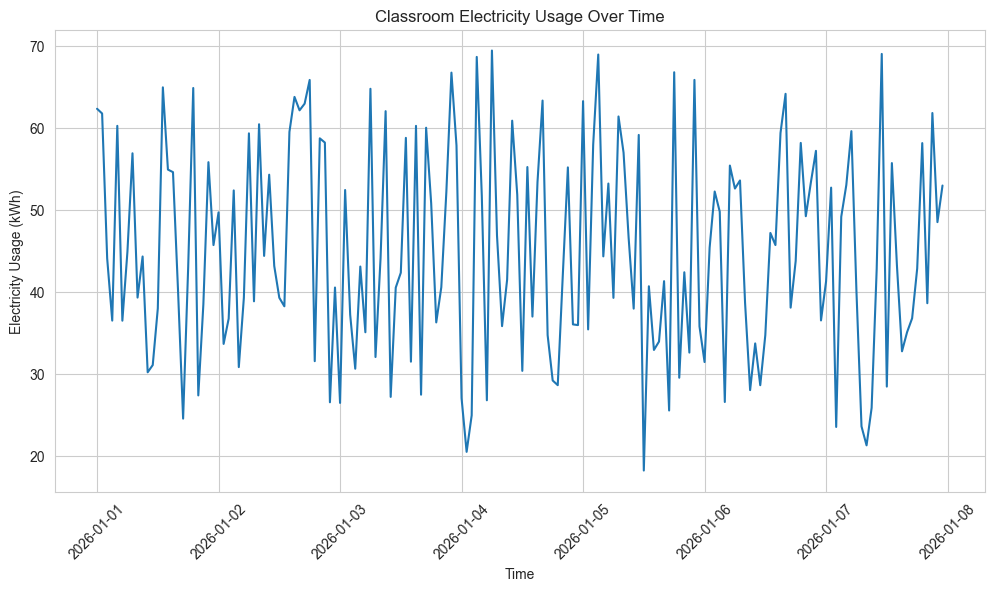

In [6]:
plt.plot(classroom_data["timestamp"], classroom_data["electricity_usage_kwh"])
plt.title("Classroom Electricity Usage Over Time")
plt.xlabel("Time")
plt.ylabel("Electricity Usage (kWh)")
plt.xticks(rotation=45)
plt.show()

In [7]:
classroom_data["timestamp"] = pd.to_datetime(classroom_data["timestamp"])
classroom_data.set_index("timestamp", inplace=True)

classroom_data.head()

,occupancy,electricity_usage_kwh
timestamp,,
2026-01-01 00:00:00,43,62.300585
2026-01-01 01:00:00,56,61.724727
2026-01-01 02:00:00,33,44.053857
2026-01-01 03:00:00,19,36.471829
2026-01-01 04:00:00,47,60.218115


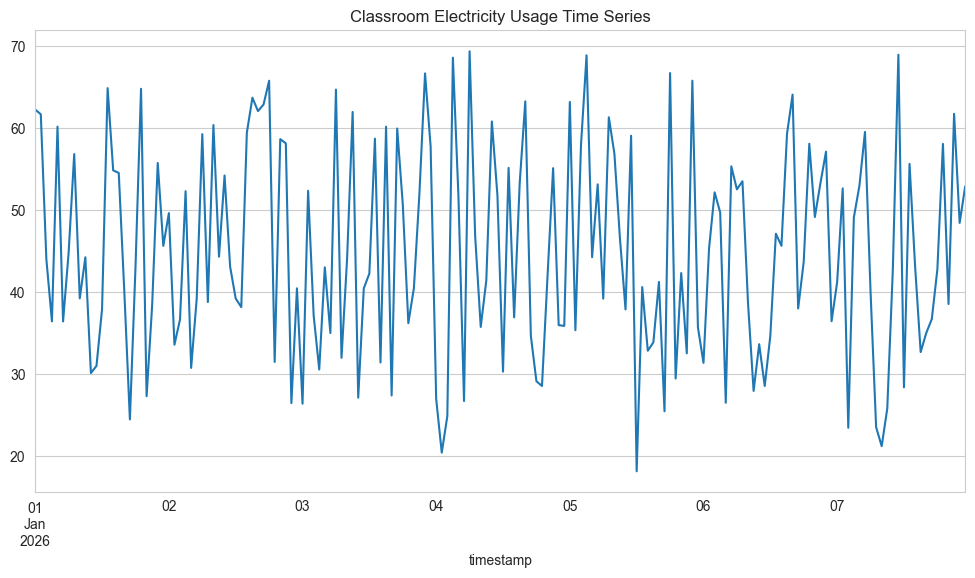

In [8]:
classroom_data["electricity_usage_kwh"].plot(title="Classroom Electricity Usage Time Series")
plt.show()

In [9]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model
model = ARIMA(classroom_data["electricity_usage_kwh"], order=(2,1,2))
model_fit = model.fit()

print(model_fit.summary())

c:\Users\ADMIN\Desktop\HackOWeek\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\ADMIN\Desktop\HackOWeek\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\ADMIN\Desktop\HackOWeek\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


                                 SARIMAX Results                                 
Dep. Variable:     electricity_usage_kwh   No. Observations:                  168
Model:                    ARIMA(2, 1, 2)   Log Likelihood                -665.450
Date:                   Wed, 11 Mar 2026   AIC                           1340.900
Time:                           20:48:32   BIC                           1356.490
Sample:                       01-01-2026   HQIC                          1347.228
                            - 01-07-2026                                         
Covariance Type:                     opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9588      0.145     -6.598      0.000      -1.244      -0.674
ar.L2         -0.0474      0.083     -0.571      0.568      -0.210       0.115
ma.L1         -0.0505      1

In [10]:
forecast = model_fit.forecast(steps=1)

print("Predicted next-hour electricity usage:")
print(forecast)

Predicted next-hour electricity usage:
2026-01-08    47.314331
Freq: h, dtype: float64


In [11]:
future_forecast = model_fit.forecast(steps=24)

future_forecast

2026-01-08 00:00:00    47.314331
2026-01-08 01:00:00    42.454153
2026-01-08 02:00:00    47.380587
2026-01-08 03:00:00    42.887523
2026-01-08 04:00:00    46.961943
2026-01-08 05:00:00    43.268375
2026-01-08 06:00:00    46.616628
2026-01-08 07:00:00    43.581411
2026-01-08 08:00:00    46.332859
2026-01-08 09:00:00    43.838649
2026-01-08 10:00:00    46.099670
2026-01-08 11:00:00    44.050037
2026-01-08 12:00:00    45.908045
2026-01-08 13:00:00    44.223746
2026-01-08 14:00:00    45.750576
2026-01-08 15:00:00    44.366493
2026-01-08 16:00:00    45.621175
2026-01-08 17:00:00    44.483796
2026-01-08 18:00:00    45.514839
2026-01-08 19:00:00    44.580190
2026-01-08 20:00:00    45.427457
2026-01-08 21:00:00    44.659403
2026-01-08 22:00:00    45.355650
2026-01-08 23:00:00    44.724497
Freq: h, Name: predicted_mean, dtype: float64

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16952\3528316636.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_index = pd.date_range(


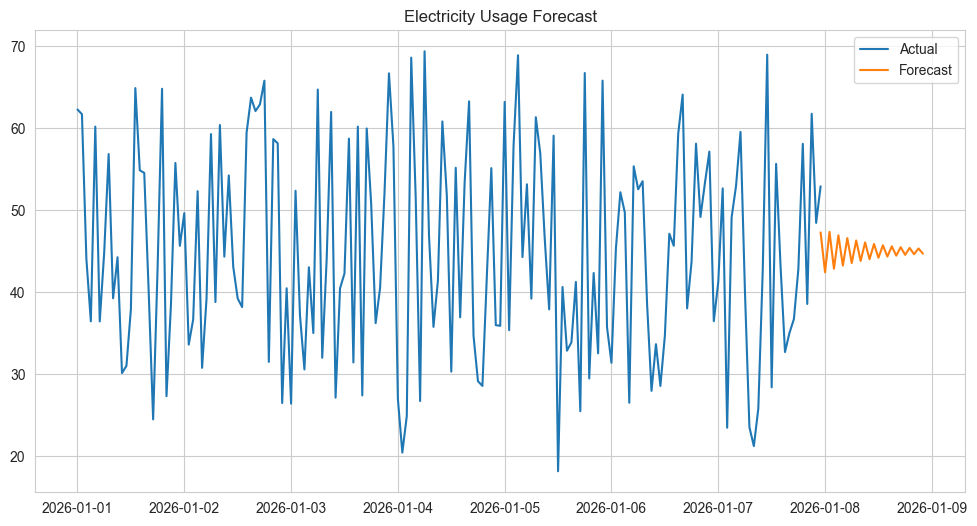

In [12]:
plt.plot(classroom_data.index, classroom_data["electricity_usage_kwh"], label="Actual")

future_index = pd.date_range(
    start=classroom_data.index[-1],
    periods=24,
    freq="H"
)

plt.plot(future_index, future_forecast, label="Forecast")

plt.legend()
plt.title("Electricity Usage Forecast")
plt.show()

In [13]:
forecast_result = model_fit.get_forecast(steps=24)

forecast_mean = forecast_result.predicted_mean
confidence_intervals = forecast_result.conf_int()

forecast_mean.head()

2026-01-08 00:00:00    47.314331
2026-01-08 01:00:00    42.454153
2026-01-08 02:00:00    47.380587
2026-01-08 03:00:00    42.887523
2026-01-08 04:00:00    46.961943
Freq: h, Name: predicted_mean, dtype: float64

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16952\3339690124.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_index = pd.date_range(


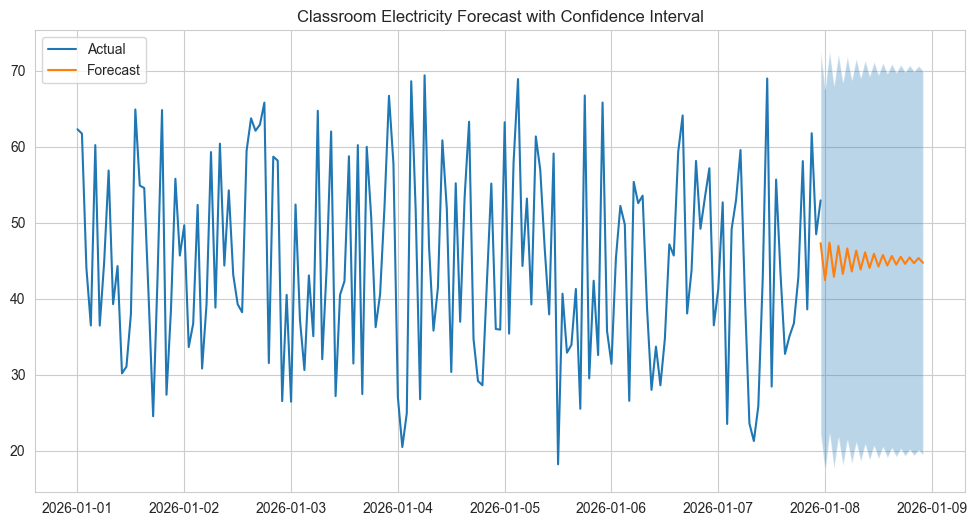

In [14]:
plt.figure()

# Actual data
plt.plot(classroom_data.index, classroom_data["electricity_usage_kwh"], label="Actual")

# Forecast
future_index = pd.date_range(
    start=classroom_data.index[-1],
    periods=24,
    freq="H"
)

plt.plot(future_index, forecast_mean, label="Forecast")

# Confidence interval shading
plt.fill_between(
    future_index,
    confidence_intervals.iloc[:,0],
    confidence_intervals.iloc[:,1],
    alpha=0.3
)

plt.legend()
plt.title("Classroom Electricity Forecast with Confidence Interval")
plt.show()

In [15]:
forecast_df = pd.DataFrame({
    "timestamp": future_index,
    "predicted_usage": forecast_mean.values,
    "lower_bound": confidence_intervals.iloc[:,0].values,
    "upper_bound": confidence_intervals.iloc[:,1].values
})

forecast_df.to_csv("../data/classroom_forecast.csv", index=False)

forecast_df.head()

,timestamp,predicted_usage,lower_bound,upper_bound
0,2026-01-07 23:00:00,47.314331,22.136065,72.492598
1,2026-01-08 00:00:00,42.454153,17.276158,67.632149
2,2026-01-08 01:00:00,47.380587,22.189890,72.571285
3,2026-01-08 02:00:00,42.887523,17.674300,68.100747
4,2026-01-08 03:00:00,46.961943,21.739397,72.184490
